In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast


In [ ]:
def exploding_genre(csv):
    """
    Explodes entries with multiple genres so every genre has it's own entry

    Parameters:
    - csv : pandas DataFrame containing dataset

    Return: 
    - genre_dummies : list containing dummy variables for each genre
    """

    data = csv.copy()
    # converting string of a list into literal list
    data['genres'] = data['genres'].apply(ast.literal_eval)

    # filtering out the genre animation, due to all movies being animation movies
    data['genres'] = data['genres'].apply(lambda g: [x for x in g if x != "Animation" and x != "TV Movie"])
    
    # breaking up genre animation, due to all movies being animation movies
    genres = data['genres'].explode()

    # assigning values to each genre to quantify them
    genre_dummies = pd.get_dummies(genres)
    genre_dummies = genre_dummies.groupby(level=0).sum()

    return genre_dummies

def exploding_studio(csv, studio_amount = 10):
    """
    Explodes entries with multiple studios so every studio has it's own entry
    
    Parameters:
    - csv : pandas DataFrame containing dataset
    - studio_amount : number of top production studio to include as features

    Return:
    - top_studios : list consisting of dummy variables for the set amount of top studios 
    """
    data = csv.copy()
    # converting string of a list into literal list
    data['production_studios'] = data['production_studios'].apply(ast.literal_eval)

    # breaking up production companios to get single categories
    studios = data['production_studios'].explode()

    # only showing the chosen amount of most frequent appearing production studios
    top_studios = studios.value_counts().head(studio_amount).index
    return top_studios

In [ ]:
# Loading data from csv file into pandas DataFrame
csv = pd.read_csv('details_anime_movies_2000.csv')


def loading_data(data,studio_amount = 10):
    """
    Loads data from DataFrame and preprocesses it
    
    Parameters:
    - data: pandas Dataframe containing dataset
    - studio_amount: number of top production studios to include as features

    Returns:
    - data: Processed DataFrame with additional feature column
    """
    # Getting list of dummies for each genre and stacking them along an axis
    genre_dummies = exploding_genre(data)
    data = pd.concat([data, genre_dummies], axis=1)

    # Getting list of dummies for amount of top studios
    top_studios = exploding_studio(data, studio_amount)

    # Creating binary column for each top studio, being 1 if the movie was produces by that studio, otherwise 0
    for studio in top_studios:
        data[studio] = data["production_studios"].apply(lambda x: int(studio in x))

    # Dependent variable (average score of the anime)
    y = data['avg_score']

    # Independent variables (Runtime, Release Year, Genre Dummies, Studio Indicators)
    X = data[
        ["runtime", "release_year"] +
        list(genre_dummies.columns) +
        list(top_studios)
    ]

    # Converting pandas objects to NumPy arrays for computing
    X = np.array(X)
    y = np.array(y)

    # Add an intercept as the first column
    X = np.c_[np.ones(X.shape[0]), X] # add intercept

    # Solve linear regression using least squares method
    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    # Create a list of feature names corresponding to coefficients
    features = ['intercept', 'runtime', 'release_year'] + list(genre_dummies.columns) + list(top_studios)

    # Storing data
    coeff_data = pd.DataFrame({
        'feature' : features,
        'coefficient' : beta
    })


    #print(coeff_data.sort_values('coefficient',ascending=False))

    return data

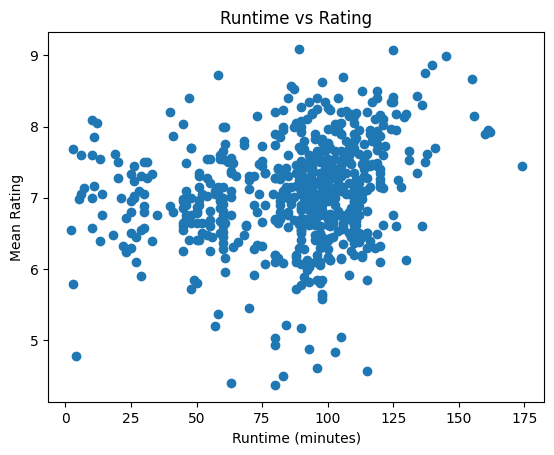

In [ ]:
def runtime_scatter_plot(csv):
    """
    Plotting Runtime and Rating on scatterplot via Mathplotlib
    
    Parameters:
    - csv : pandas DataFrame containing dataset

    """
    data = loading_data(csv) # Loading data
    plt.scatter(data['runtime'], data['avg_score']) # Plotting Runtime and Rating across scatterplot
    plt.xlabel("Runtime (minutes)") # Labeling x-axis
    plt.ylabel("Mean Rating")   # Labeling y-axis
    plt.title("Runtime vs Rating") # Title of plot
    plt.show()

runtime_scatter_plot(csv.copy())

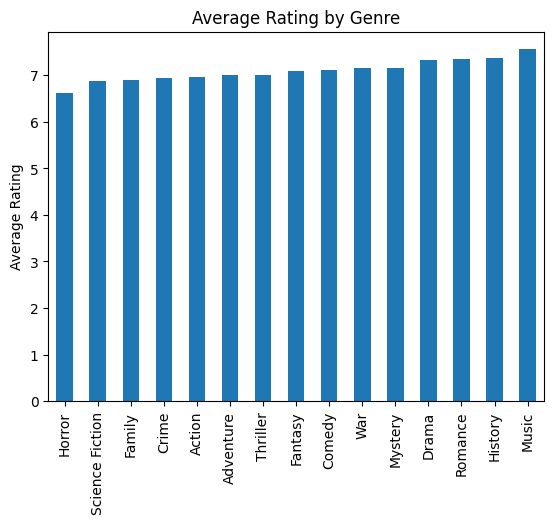

In [ ]:
def genre_bar_chart_rating(csv):
    """
    Plotting Ratings across Genres on barplot via Mathplotlib

    Parameters : 
    - csv : pandas dataframe containing dataset
    """
    data = loading_data(csv) # Loading data
    genre_means = {}

    # Getting genre dummy variables from copy of original data to avoid modifying the original dataset
    genre_dummies = exploding_genre(csv.copy()) #
    for g in genre_dummies.columns:

        # Only compute average score for rows where the genre is present
        genre_means[g] = data[data[g] == 1]['avg_score'].mean() # Calculating average score for each single Genre
    
    # Convert dictionary to pandas Series for easier plotting and sort values by rating
    pd.Series(genre_means).sort_values().plot(kind='bar')
    
    plt.ylabel("Average Rating")
    plt.title("Average Rating by Genre")
    plt.show()

genre_bar_chart_rating(csv)

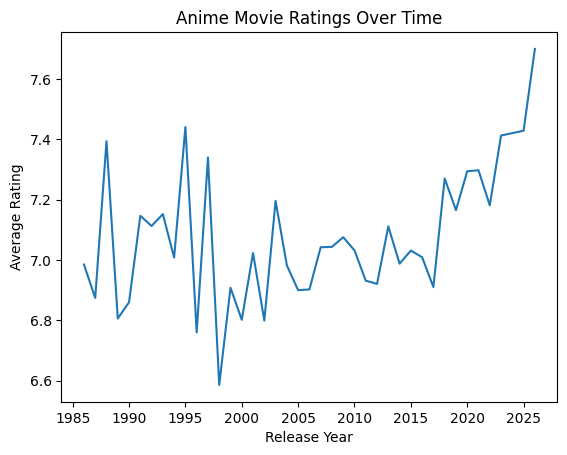

In [ ]:
def ratings_over_time_plot(csv):
    """
    Plotting Runtime and Rating on scatterplot via Mathplotlib
    
    Parameters:
    - csv : pandas DataFrame containing dataset
    """
    data = loading_data(csv) # Loading data
    year_means = data.groupby('release_year')["avg_score"].mean() # Calculating average score of all anime movies per year

    year_means.plot() # Plotting data 

    plt.xlabel("Release Year")
    plt.ylabel("Average Rating")
    plt.title("Anime Movie Ratings Over Time")
    plt.show()

ratings_over_time_plot(csv)

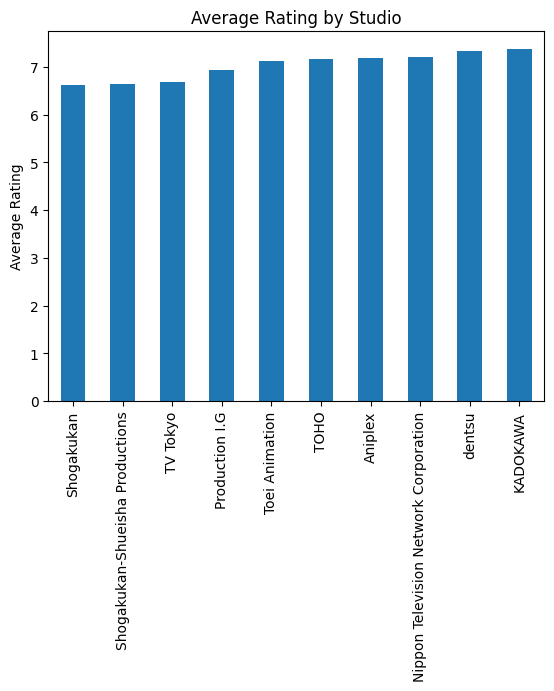

In [ ]:
def ratings_over_top_studios(csv, studios_amount = 10):
    """
    Plot average ratings across production studios using a bar chart

    Parameters: 
    - csv : pandas DataFrame containing the dataset
    - studio-amount : number of top production studios to include as features 
    """
    data = loading_data(csv,studios_amount)

    studio_scores = {}
    
    # Getting top_studio dummy variables from copy of original data to avoid modifying the original dataset
    top_studios = exploding_studio(csv.copy(), studios_amount)
    
    for s in top_studios:
        # Only compute average score for rows where the genre is present
        studio_scores[s] = data[data[s] == 1]['avg_score'].mean()

    # Convert dictionary to pandas Series for easier plotting and sort values by rating
    pd.Series(studio_scores).sort_values().plot(kind="bar")

    plt.ylabel("Average Rating")
    plt.title("Average Rating by Studio")
    plt.show()

ratings_over_top_studios(csv)